# YOLOv10s Passenger Counting
Train + validate with fair settings, faster training, and viva-proof artifact export.


In [1]:
# Cell 1 - Environment, imports, and helpers
import json
import os
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from ultralytics import YOLO


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "ai_models" / "passenger_counting").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing ai_models/passenger_counting")


def pick_column(columns, candidates):
    column_set = set(columns)
    for name in candidates:
        if name in column_set:
            return name
    return None


def read_best_epoch_from_csv(results_csv: Path):
    if not results_csv.exists():
        return None
    df = pd.read_csv(results_csv)
    df.columns = [str(c).strip() for c in df.columns]
    metric_col = pick_column(df.columns, ["metrics/mAP50-95(B)", "metrics/mAP50-95"])
    if metric_col is None or df.empty:
        return None
    epoch_col = pick_column(df.columns, ["epoch", "Epoch"])
    best_idx = int(df[metric_col].idxmax())
    best_epoch = int(df.loc[best_idx, epoch_col]) if epoch_col else best_idx
    last_epoch = int(df[epoch_col].iloc[-1]) if epoch_col else len(df) - 1
    return {
        "best_epoch": best_epoch,
        "best_metric_column": metric_col,
        "best_mAP50_95": float(df.loc[best_idx, metric_col]),
        "last_epoch": last_epoch,
        "stopped_early": bool(best_epoch < last_epoch),
    }


def find_best_checkpoint(model_name: str, run_root: Path, passenger_root: Path, project_root: Path):
    candidates = [
        run_root / model_name,
        passenger_root / "runs" / "detect" / "separate_model_notebooks" / model_name,
        passenger_root / "runs" / "detect" / "model_comparison" / model_name,
        project_root / "runs" / "detect" / "separate_model_notebooks" / model_name,
        project_root / "runs" / "detect" / "model_comparison" / model_name,
    ]
    for run_dir in candidates:
        best_pt = run_dir / "weights" / "best.pt"
        if best_pt.exists():
            return best_pt, run_dir
    return None, None


NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(NOTEBOOK_DIR)
PASSENGER_ROOT = PROJECT_ROOT / "ai_models" / "passenger_counting"
DATA_YAML = PASSENGER_ROOT / "datasets" / "smart_bus_final" / "data.yaml"

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

print("Project root:", PROJECT_ROOT)
print("Passenger root:", PASSENGER_ROOT)
print("Dataset YAML:", DATA_YAML)


Project root: C:\suttle project\smart-shuttle-ai-system
Passenger root: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting
Dataset YAML: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\datasets\smart_bus_final\data.yaml


In [2]:
# Cell 2 - Fair training configuration (YOLOv10s)
MODEL_KEY = "yolov10s"
MODEL_NAME = "YOLOv10s"
BASE_WEIGHT_FILE = "yolov10s.pt"
BASE_WEIGHT_PATH = PASSENGER_ROOT / BASE_WEIGHT_FILE
BASE_WEIGHT = str(BASE_WEIGHT_PATH if BASE_WEIGHT_PATH.exists() else BASE_WEIGHT_FILE)

# Fair comparison settings (same across all 4 model notebooks)
EPOCHS = 150
PATIENCE = 20
IMG_SIZE = 640
PREFERRED_BATCH = 16
FALLBACK_BATCH = 8  # If batch=16 causes CUDA out of memory, fallback to 8.
BATCH = PREFERRED_BATCH
VAL_BATCH = PREFERRED_BATCH
WORKERS = 8
DEVICE = 0  # Force NVIDIA GPU (CUDA:0)

RUN_TRAINING = True
CACHE_IMAGES = "disk"  # FIX: avoids RAM cache warning / low available RAM issue
USE_AMP = True
PLOTS = True

RUN_ROOT = PASSENGER_ROOT / "runs" / "detect" / "separate_model_notebooks"
ARTIFACT_DIR = RUN_ROOT / "artifacts"
BEST_MODELS_DIR = ARTIFACT_DIR / "best_models"
CHART_DIR = ARTIFACT_DIR / "per_model_charts"
RUN_DIR = RUN_ROOT / MODEL_NAME

# Viva-proof export folders
VIVA_PROOF_ROOT = PROJECT_ROOT / "viva_model_comparison_proof"
MODEL_PROOF_DIR = VIVA_PROOF_ROOT / MODEL_KEY

for folder in [RUN_ROOT, ARTIFACT_DIR, BEST_MODELS_DIR, CHART_DIR, RUN_DIR, VIVA_PROOF_ROOT, MODEL_PROOF_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Base weight:", BASE_WEIGHT)
print("Run dir:", RUN_DIR)
print("Proof dir:", MODEL_PROOF_DIR)
print("Dataset:", DATA_YAML)
print("Image size:", IMG_SIZE)
print("Epochs:", EPOCHS, "| Patience:", PATIENCE)
print("Batch(train):", PREFERRED_BATCH, "| Fallback batch:", FALLBACK_BATCH, "| Batch(val):", VAL_BATCH)
print("Workers:", WORKERS, "| Cache:", CACHE_IMAGES, "| AMP:", USE_AMP, "| Plots:", PLOTS)
print("Cache note: using cache='disk' is safer than cache=True/RAM for long YOLO training on this dataset.")
print("Device:", DEVICE, "(forced CUDA GPU)")
print("Run training:", RUN_TRAINING)


Model: YOLOv10s
Base weight: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\yolov10s.pt
Run dir: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\YOLOv10s
Proof dir: C:\suttle project\smart-shuttle-ai-system\viva_model_comparison_proof\yolov10s
Dataset: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\datasets\smart_bus_final\data.yaml
Image size: 640
Epochs: 150 | Patience: 20
Batch(train): 16 | Fallback batch: 8 | Batch(val): 16
Workers: 8 | Cache: disk | AMP: True | Plots: True
Cache note: using cache='disk' is safer than cache=True/RAM for long YOLO training on this dataset.
Device: 0 (forced CUDA GPU)
Run training: True


In [3]:
# Cell 3 - GPU check (run before training)
cuda_available = torch.cuda.is_available()
gpu_name = torch.cuda.get_device_name(0) if cuda_available else "No NVIDIA GPU detected"
cuda_version = torch.version.cuda if torch.version.cuda else "CUDA not available in current torch build"
training_target = "GPU (CUDA:0)" if cuda_available else "CPU"

print("torch.cuda.is_available():", cuda_available)
print("GPU name:", gpu_name)
print("CUDA version:", cuda_version)
print("Training will use:", training_target)
print("Note: NPU is not used for YOLO training. YOLO training should use NVIDIA RTX GPU with CUDA.")

if not cuda_available:
    print("WARNING: CUDA is unavailable. This notebook is configured with device=0 and expects CUDA GPU training.")


torch.cuda.is_available(): True
GPU name: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA version: 12.8
Training will use: GPU (CUDA:0)
Note: NPU is not used for YOLO training. YOLO training should use NVIDIA RTX GPU with CUDA.


In [4]:
# Cell 4 - Train model (early stopping + safe cache + fast settings)
# FIX explanation:
# cache=True means RAM cache. Your log showed RAM cache warnings.
# cache="disk" keeps training faster than no cache but avoids filling system RAM.
training_status = {}
start_time = time.time()


def train_once(batch_size: int):
    model = YOLO(BASE_WEIGHT)
    return model.train(
        data=str(DATA_YAML),
        epochs=EPOCHS,
        imgsz=IMG_SIZE,
        batch=batch_size,
        patience=PATIENCE,
        device=DEVICE,
        workers=WORKERS,
        cache=CACHE_IMAGES,
        amp=USE_AMP,
        optimizer="AdamW",
        lr0=0.001,
        cos_lr=True,
        close_mosaic=10,
        project=str(RUN_ROOT),
        name=MODEL_NAME,
        exist_ok=True,
        plots=PLOTS,
        pretrained=True,
        verbose=True,
    )


if not RUN_TRAINING:
    training_status = {
        "status": "skipped",
        "reason": "RUN_TRAINING=False",
        "run_dir": str(RUN_DIR),
    }
    print("Training skipped")
else:
    attempted_batches = [PREFERRED_BATCH]
    batch_used = PREFERRED_BATCH

    try:
        try:
            train_result = train_once(PREFERRED_BATCH)
        except RuntimeError as exc:
            error_text = str(exc).lower()
            cuda_oom = ("out of memory" in error_text) or ("cuda" in error_text and "memory" in error_text)
            if cuda_oom and PREFERRED_BATCH != FALLBACK_BATCH:
                print("CUDA out of memory with batch=16. Retrying with batch=8.")
                print("Fallback rule: if batch=16 causes CUDA out of memory, use batch=8.")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                batch_used = FALLBACK_BATCH
                attempted_batches.append(FALLBACK_BATCH)
                train_result = train_once(FALLBACK_BATCH)
            elif ("memory" in error_text or "ram" in error_text) and CACHE_IMAGES:
                print("Memory/cache issue detected. Retrying with cache=False and fallback batch.")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                globals()["CACHE_IMAGES"] = False
                batch_used = FALLBACK_BATCH
                attempted_batches.append(FALLBACK_BATCH)
                train_result = train_once(FALLBACK_BATCH)
            else:
                raise

        resolved_run_dir = Path(getattr(train_result, "save_dir", RUN_DIR))
        training_status = {
            "status": "completed",
            "run_dir": str(resolved_run_dir),
            "batch_used": int(batch_used),
            "attempted_batches": attempted_batches,
            "elapsed_minutes": round((time.time() - start_time) / 60, 2),
        }
        print("Training complete:", resolved_run_dir)
        print("Batch used:", batch_used)
    except Exception as exc:
        training_status = {
            "status": "failed",
            "error": str(exc),
            "attempted_batches": attempted_batches,
            "elapsed_minutes": round((time.time() - start_time) / 60, 2),
        }
        print("Training failed:", exc)

training_status


Ultralytics 8.4.41  Python-3.11.9 torch-2.12.0.dev20260301+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\datasets\smart_bus_final\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\suttle project\smart-shuttle-ai-system\ai_models\passe

{'status': 'completed',
 'run_dir': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\runs\\detect\\separate_model_notebooks\\YOLOv10s',
 'batch_used': 16,
 'attempted_batches': [16],
 'elapsed_minutes': 51.47}

In [7]:
# Cell 5 - Validate model and export viva-proof files (FIXED SAFE VERSION)
# This cell is also safe if Cell 4 failed or was not run in the current kernel.

from pathlib import Path
import shutil
import json
from ultralytics import YOLO

# ---------------------------------------------------------
# 0. Safety checks and fallbacks
# ---------------------------------------------------------

# This cell should normally run AFTER Cell 1, Cell 2, Cell 3, and Cell 4.
# But these fallbacks prevent NameError if training_status was not created.

if "training_status" not in globals():
    training_status = {
        "status": "not_available",
        "reason": "Cell 4 was not run in this kernel session.",
    }
    print("⚠️ training_status was not found. Using safe fallback.")

required_names = [
    "PROJECT_ROOT",
    "PASSENGER_ROOT",
    "DATA_YAML",
    "RUN_ROOT",
    "RUN_DIR",
    "MODEL_NAME",
    "MODEL_KEY",
    "BASE_WEIGHT",
    "IMG_SIZE",
    "EPOCHS",
    "PATIENCE",
    "PREFERRED_BATCH",
    "FALLBACK_BATCH",
    "VAL_BATCH",
    "DEVICE",
    "WORKERS",
    "CACHE_IMAGES",
    "USE_AMP",
    "ARTIFACT_DIR",
    "BEST_MODELS_DIR",
    "MODEL_PROOF_DIR",
]

missing_names = [name for name in required_names if name not in globals()]

if missing_names:
    raise RuntimeError(
        "Some required variables are missing:\n"
        f"{missing_names}\n\n"
        "Fix: Run Cell 1 and Cell 2 first. Then run Cell 4 for training, "
        "and finally run this Cell 5."
    )

if not Path(DATA_YAML).exists():
    raise FileNotFoundError(f"Dataset YAML not found: {DATA_YAML}")

# Create output folders safely
for folder in [ARTIFACT_DIR, BEST_MODELS_DIR, MODEL_PROOF_DIR]:
    Path(folder).mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Locate best.pt safely
# ---------------------------------------------------------

run_dir = Path(training_status.get("run_dir", RUN_DIR))
best_pt = run_dir / "weights" / "best.pt"

print("Checking expected best.pt:")
print(best_pt)

def search_all_best_checkpoints():
    """Search possible project folders for best.pt files."""
    search_roots = [
        Path(RUN_ROOT),
        Path(PASSENGER_ROOT),
        Path(PROJECT_ROOT),
        Path.cwd(),
    ]

    all_best_files = []

    for root in search_roots:
        if root.exists():
            try:
                all_best_files.extend(list(root.rglob("best.pt")))
            except Exception as exc:
                print(f"Could not search {root}: {exc}")

    # Remove duplicates while keeping order
    return list(dict.fromkeys(all_best_files))


if not best_pt.exists():
    print("\nExpected best.pt not found. Searching project folders...")

    all_best_files = search_all_best_checkpoints()

    print("\nAvailable best.pt files:")
    if all_best_files:
        for file in all_best_files:
            print(file)
    else:
        print("No best.pt files found in searched folders.")

    # Priority 1: exact model name folder match
    matching_best_files = [
        file for file in all_best_files
        if MODEL_NAME.lower() in str(file).lower()
    ]

    # Priority 2: model key folder match
    if not matching_best_files:
        matching_best_files = [
            file for file in all_best_files
            if MODEL_KEY.lower() in str(file).lower()
        ]

    if matching_best_files:
        best_pt = Path(matching_best_files[0])
        run_dir = best_pt.parent.parent
        print("\nUsing matched best.pt:")
        print(best_pt)

    else:
        # Priority 3: existing helper function
        fallback_best, fallback_dir = find_best_checkpoint(
            MODEL_NAME,
            Path(RUN_ROOT),
            Path(PASSENGER_ROOT),
            Path(PROJECT_ROOT),
        )

        if fallback_best is not None:
            best_pt = Path(fallback_best)
            run_dir = Path(fallback_dir)
            print("\nUsing fallback best.pt:")
            print(best_pt)

        else:
            raise FileNotFoundError(
                f"\nBest checkpoint not found for {MODEL_NAME}.\n\n"
                f"Expected path:\n{best_pt}\n\n"
                "Meaning: this model has not been trained successfully yet, "
                "or the output folder name is different.\n\n"
                "Fix:\n"
                "1. Run Cell 1 and Cell 2.\n"
                "2. Set RUN_TRAINING = True in Cell 2.\n"
                "3. Run Cell 4 and wait until training finishes.\n"
                "4. Run Cell 5 again.\n"
            )

# ---------------------------------------------------------
# 2. Validate model
# ---------------------------------------------------------

print("\nLoading model:")
print(best_pt)

validator = YOLO(str(best_pt))

val_batch = int(training_status.get("batch_used", VAL_BATCH))

val_result = validator.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMG_SIZE,
    batch=val_batch,
    device=DEVICE,
    verbose=False,
)

precision = float(getattr(val_result.box, "mp", 0.0))
recall = float(getattr(val_result.box, "mr", 0.0))
map50 = float(getattr(val_result.box, "map50", 0.0))
map5095 = float(getattr(val_result.box, "map", 0.0))

score = (
    (0.55 * map5095)
    + (0.25 * map50)
    + (0.10 * precision)
    + (0.10 * recall)
)

# ---------------------------------------------------------
# 3. Copy best model
# ---------------------------------------------------------

copied_best = Path(BEST_MODELS_DIR) / f"{MODEL_NAME}_best.pt"
shutil.copy2(best_pt, copied_best)

# ---------------------------------------------------------
# 4. Copy viva-proof files
# ---------------------------------------------------------

artifact_sources = {
    "best.pt": best_pt,
    "last.pt": run_dir / "weights" / "last.pt",
    "results.csv": run_dir / "results.csv",
    "results.png": run_dir / "results.png",
    "args.yaml": run_dir / "args.yaml",
}

copied_proof_files = {}

for file_name, source_path in artifact_sources.items():
    source_path = Path(source_path)
    target_path = Path(MODEL_PROOF_DIR) / file_name

    if source_path.exists():
        shutil.copy2(source_path, target_path)
        copied_proof_files[file_name] = str(target_path)
    else:
        copied_proof_files[file_name] = ""
        print(f"Missing artifact not copied: {source_path}")

# ---------------------------------------------------------
# 5. Read best epoch info
# ---------------------------------------------------------

if copied_proof_files.get("results.csv"):
    results_csv = Path(copied_proof_files["results.csv"])
else:
    results_csv = Path(artifact_sources["results.csv"])

best_epoch_info = None

if results_csv.exists():
    best_epoch_info = read_best_epoch_from_csv(results_csv)
else:
    print("results.csv not found, so best epoch info was skipped.")

# ---------------------------------------------------------
# 6. Save summary JSON
# ---------------------------------------------------------

summary = {
    "Model": MODEL_NAME,
    "Model Key": MODEL_KEY,
    "Base Weight": BASE_WEIGHT,
    "Dataset YAML": str(DATA_YAML),
    "Image Size": IMG_SIZE,
    "Epochs": EPOCHS,
    "Patience": PATIENCE,
    "Batch Preferred": PREFERRED_BATCH,
    "Batch Fallback": FALLBACK_BATCH,
    "Batch Used": val_batch,
    "Device": DEVICE,
    "Workers": WORKERS,
    "Cache": CACHE_IMAGES,
    "AMP": USE_AMP,

    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "mAP50": round(map50, 4),
    "mAP50-95": round(map5095, 4),
    "Score": round(score, 4),

    "Run Folder": str(run_dir),
    "Best Checkpoint": str(best_pt),
    "Copied Best Checkpoint": str(copied_best),
    "Results CSV": str(results_csv) if results_csv.exists() else "",

    "Best Epoch": best_epoch_info.get("best_epoch") if best_epoch_info else None,
    "Best Epoch mAP50-95": (
        round(best_epoch_info.get("best_mAP50_95", 0.0), 4)
        if best_epoch_info else None
    ),
    "Last Epoch": best_epoch_info.get("last_epoch") if best_epoch_info else None,
    "Stopped Early": best_epoch_info.get("stopped_early") if best_epoch_info else None,

    "Proof Folder": str(MODEL_PROOF_DIR),
    "Proof Files": copied_proof_files,
}

summary_path = Path(ARTIFACT_DIR) / f"{MODEL_KEY}_summary.json"

with open(summary_path, "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

proof_summary_path = Path(MODEL_PROOF_DIR) / "summary.json"

with open(proof_summary_path, "w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

# ---------------------------------------------------------
# 7. Print result
# ---------------------------------------------------------

print("\n✅ Validation completed successfully.")
print("Saved summary:", summary_path)
print("Saved proof summary:", proof_summary_path)
print("Proof folder:", MODEL_PROOF_DIR)
print("Copied files:", [k for k, v in copied_proof_files.items() if v])

if best_epoch_info:
    print(
        f"Best epoch: {best_epoch_info['best_epoch']} "
        f"(mAP50-95={best_epoch_info['best_mAP50_95']:.4f}) "
        f"| Last epoch: {best_epoch_info['last_epoch']}"
    )

summary


Checking expected best.pt:
C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\YOLOv10s\weights\best.pt

Loading model:
C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\YOLOv10s\weights\best.pt
Ultralytics 8.4.41  Python-3.11.9 torch-2.12.0.dev20260301+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Laptop GPU, 8151MiB)
YOLOv10s summary (fused): 106 layers, 7,218,387 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 140.830.7 MB/s, size: 725.9 KB)
val: Scanning C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\datasets\smart_bus_final\labels\val.cache... 488 images, 52 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 488/488  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 31/31 11.0it/s 2.8s0.2s
                   all        488       9028      0.938      0.947      0.9

{'Model': 'YOLOv10s',
 'Model Key': 'yolov10s',
 'Base Weight': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\yolov10s.pt',
 'Dataset YAML': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\datasets\\smart_bus_final\\data.yaml',
 'Image Size': 640,
 'Epochs': 150,
 'Patience': 20,
 'Batch Preferred': 16,
 'Batch Fallback': 8,
 'Batch Used': 16,
 'Device': 0,
 'Workers': 8,
 'Cache': 'disk',
 'AMP': True,
 'Precision': 0.9382,
 'Recall': 0.9467,
 'mAP50': 0.983,
 'mAP50-95': 0.8219,
 'Score': 0.8863,
 'Run Folder': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\runs\\detect\\separate_model_notebooks\\YOLOv10s',
 'Best Checkpoint': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\runs\\detect\\separate_model_notebooks\\YOLOv10s\\weights\\best.pt',
 'Copied Best Checkpoint': 'C:\\suttle project\\smart-shuttle-ai-system\\ai_models\\passenger_counting\\runs\\detect\\separate_

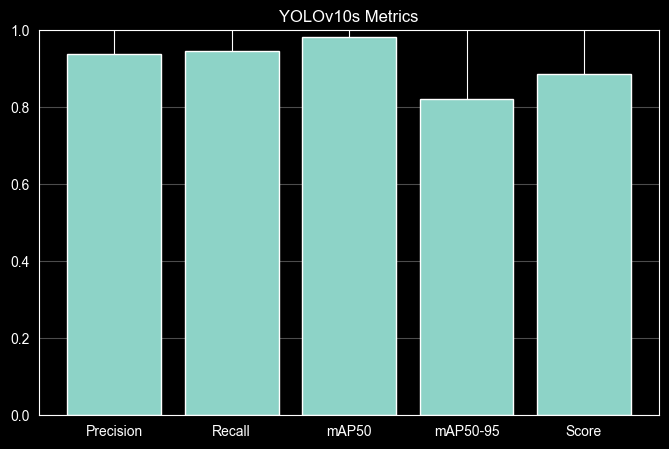

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\per_model_charts\yolov10s_metrics.png


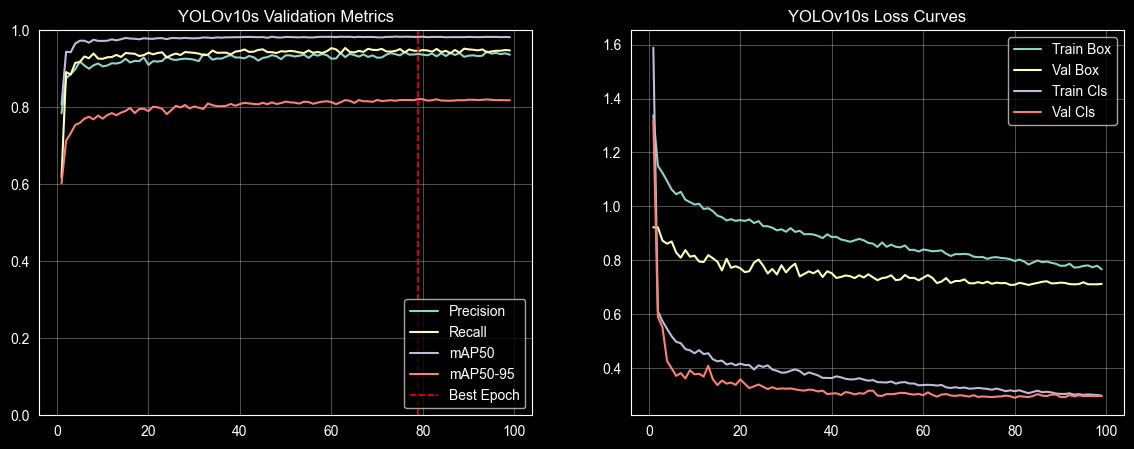

Saved: C:\suttle project\smart-shuttle-ai-system\ai_models\passenger_counting\runs\detect\separate_model_notebooks\artifacts\per_model_charts\yolov10s_training_curves.png


In [8]:
# Cell 6 - Charts (metrics + training curves)
metrics_df = pd.DataFrame(
    [
        {"Metric": "Precision", "Value": summary["Precision"]},
        {"Metric": "Recall", "Value": summary["Recall"]},
        {"Metric": "mAP50", "Value": summary["mAP50"]},
        {"Metric": "mAP50-95", "Value": summary["mAP50-95"]},
        {"Metric": "Score", "Value": summary["Score"]},
    ]
)

plt.figure(figsize=(8, 5))
plt.bar(metrics_df["Metric"], metrics_df["Value"])
plt.ylim(0, 1.0)
plt.title(f"{MODEL_NAME} Metrics")
plt.grid(axis="y", alpha=0.3)
metric_chart_path = CHART_DIR / f"{MODEL_KEY}_metrics.png"
plt.savefig(metric_chart_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", metric_chart_path)

if summary["Results CSV"]:
    csv_path = Path(summary["Results CSV"])
    if csv_path.exists():
        train_df = pd.read_csv(csv_path)
        train_df.columns = [str(c).strip() for c in train_df.columns]
        epoch_col = pick_column(train_df.columns, ["epoch", "Epoch"]) or train_df.columns[0]

        precision_col = pick_column(train_df.columns, ["metrics/precision(B)", "metrics/precision"])
        recall_col = pick_column(train_df.columns, ["metrics/recall(B)", "metrics/recall"])
        map50_col = pick_column(train_df.columns, ["metrics/mAP50(B)", "metrics/mAP50"])
        map5095_col = pick_column(train_df.columns, ["metrics/mAP50-95(B)", "metrics/mAP50-95"])

        train_box_col = pick_column(train_df.columns, ["train/box_loss"])
        val_box_col = pick_column(train_df.columns, ["val/box_loss"])
        train_cls_col = pick_column(train_df.columns, ["train/cls_loss"])
        val_cls_col = pick_column(train_df.columns, ["val/cls_loss"])

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        metric_drawn = False
        for label, col in [
            ("Precision", precision_col),
            ("Recall", recall_col),
            ("mAP50", map50_col),
            ("mAP50-95", map5095_col),
        ]:
            if col:
                axes[0].plot(train_df[epoch_col], train_df[col], label=label)
                metric_drawn = True

        if summary.get("Best Epoch") is not None:
            axes[0].axvline(summary["Best Epoch"], color="red", linestyle="--", linewidth=1.2, label="Best Epoch")

        axes[0].set_ylim(0, 1.0)
        axes[0].set_title(f"{MODEL_NAME} Validation Metrics")
        axes[0].grid(alpha=0.3)
        if metric_drawn:
            axes[0].legend(loc="lower right")

        loss_drawn = False
        for label, col in [
            ("Train Box", train_box_col),
            ("Val Box", val_box_col),
            ("Train Cls", train_cls_col),
            ("Val Cls", val_cls_col),
        ]:
            if col:
                axes[1].plot(train_df[epoch_col], train_df[col], label=label)
                loss_drawn = True

        axes[1].set_title(f"{MODEL_NAME} Loss Curves")
        axes[1].grid(alpha=0.3)
        if loss_drawn:
            axes[1].legend(loc="upper right")

        train_chart_path = CHART_DIR / f"{MODEL_KEY}_training_curves.png"
        plt.savefig(train_chart_path, dpi=220, bbox_inches="tight")
        plt.show()
        print("Saved:", train_chart_path)
    else:
        print("results.csv path not found:", csv_path)
else:
    print("No results.csv available for this model run.")


## Viva Notes
- **Why early stopping is used:** `epochs=150` with `patience=20` stops training when validation does not improve, saving time while keeping strong checkpoints.
- **Why GPU is used:** `device=0` forces CUDA training on NVIDIA RTX GPU, which is much faster than CPU for YOLO.
- **Why same settings are used:** same dataset, image size, epochs, patience, batch strategy, workers, cache, AMP, and device make model comparison fair.
- **NPU note:** NPU is not used for YOLO training. YOLO training should use NVIDIA RTX GPU with CUDA.
- **Proof output:** `best.pt`, `last.pt`, `results.csv`, `results.png`, and `args.yaml` are copied to `viva_model_comparison_proof/` per model.
